In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [7]:
df = pd.read_csv(r"C:\Users\AdminOS\Desktop\Machine\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
print(df.head)

<bound method NDFrame.head of      total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]>


In [ ]:
print(df.describe)

<bound method NDFrame.describe of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DS

In [ ]:
print(df.duplicated)

<bound method DataFrame.duplicated of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service           

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df = df.drop("customerID", axis=1)


In [ ]:
yes_no_cols = ["Partner", "Dependents", "PhoneService", "MultipleLines",
               "OnlineSecurity", "OnlineBackup", "DeviceProtection",
               "TechSupport", "StreamingTV", "StreamingMovies",
               "PaperlessBilling", "Churn"]

for col in yes_no_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})


In [ ]:
df = pd.get_dummies(df, columns=["gender", "InternetService", "Contract", "PaymentMethod"], drop_first=True)


In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].mean(), inplace=True)


C:\Users\AdminOS\AppData\Local\Temp\ipykernel_57552\2540379823.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].mean(), inplace=True)


In [ ]:
y = df["TotalCharges"]
X = df.drop("TotalCharges", axis=1)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)



In [ ]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)

lin_r2 = r2_score(y_test, y_pred_lin)
lin_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lin))
print(lin_rmse)
print(lin_r2)

699.689165911041
0.9058314479928053


In [ ]:
knn_model = KNeighborsRegressor(n_neighbors=7)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

knn_r2 = r2_score(y_test, y_pred_knn)
knn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn))
print(knn_r2)
print(knn_rmse)

0.9980130286151467
101.63610410165695


In [ ]:
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train)
y_pred_poly = poly_model.predict(X_poly_test)

poly_r2 = r2_score(y_test, y_pred_poly)
poly_rmse = np.sqrt(mean_squared_error(y_test, y_pred_poly))
print(poly_r2)
print(poly_rmse)

0.9982841703706686
94.44724290562756


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

In [ ]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=4,
    random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("R² Score:", r2)
print("RMSE:", rmse)

R² Score: 0.9987764756573378
RMSE: 79.75510849861695


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor


In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 12, 16, None],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 3]
}

grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    scoring='r2'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best R²:", grid.best_score_)

# بناء موديل جديد بأفضل باراميترز
best_rf = grid.best_estimator_

y_pred = best_rf.predict(X_test)

print("Test R²:", r2_score(y_test, y_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


Best Parameters: {'max_depth': 12, 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 300}
Best R²: 0.9986490075520038
Test R²: 0.9987747936990167
Test RMSE: 79.80990867452728


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

# -----------------------------------
# XGBoost Regressor
# -----------------------------------

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost R²:", r2_score(y_test, y_pred_xgb))
print("XGBoost RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))


XGBoost R²: 0.998222072090834
XGBoost RMSE: 96.14114204091364


In [ ]:
!pip install xgboost


   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB 330.3 kB/s eta 0:03:38
   ---------------------------------------- 0.0/72.0 MB 281.8 kB/s eta 0:04:16
   ---------------------------------------- 0.1/72.0 MB 435.7 kB/s eta 0:02:46
   ---------------------------------------- 0.1/72.0 MB 595.3 kB/s eta 0:02:01
   ---------------------------------------- 0.2/72.0 MB 654.6 kB/s eta 0:01:50
   ---------------------------------------- 0.2/72.0 MB 731.4 kB/s eta 0:01:39
   ---------------------------------------- 0.3/72.0 MB 787.7 kB/s eta 0:01:32
   ---------------------------------------- 0.3/72.0 MB 863.3 kB/s eta 0:01:24
   ---------------------------------------- 0.4/72.0 MB 890.4 kB/s eta 0:01:21
   ---------------------------------------- 0.4/72.0 MB 890.4 kB/s eta 0:01:21
   ---------------------------------------- 0.5/72.0 MB 938.8 kB/s eta


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\AdminOS\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
from sklearn.ensemble import StackingRegressor


In [ ]:
base_models = [
('rf', RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)),
('lr', LinearRegression()),
('xgb', XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42))
]

In [ ]:
stack_model = StackingRegressor(
estimators=base_models,
final_estimator=RandomForestRegressor(),
passthrough=True
)

In [ ]:
stack_model.fit(X_train, y_train)

,estimators,"[('rf', ...), ('lr', ...), ...]"
,final_estimator,RandomForestRegressor()
,cv,None
,n_jobs,None
,passthrough,True
,verbose,0
,n_estimators,100
,criterion,'squared_error'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1


In [ ]:
from sklearn.metrics import make_scorer, r2_score, mean_squared_error

grid_search = GridSearchCV(
estimator=stack_model,
param_grid=param_grid,
cv=3,
scoring=make_scorer(r2_score),
n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best R2:", grid_search.best_score_)

ValueError: Invalid parameter 'max_depth' for estimator StackingRegressor(estimators=[('rf',
                               RandomForestRegressor(max_depth=5,
                                                     random_state=42)),
                              ('lr', LinearRegression()),
                              ('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            featu...
                                            interaction_constraints=None,
                                            learning_rate=0.1, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=3,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=100, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                  final_estimator=RandomForestRegressor(), passthrough=True). Valid parameters are: ['cv', 'estimators', 'final_estimator', 'n_jobs', 'passthrough', 'verbose'].

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

y_pred = stack_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
mse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 92.1647839216633
R2 Score: 0.9983660994747473
RMSE: 92.1647839216633


Stacking Adwash


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import make_scorer, r2_score, mean_squared_error
import numpy as np



base_models = [
('rf', RandomForestRegressor(random_state=42)),
('lr', LinearRegression()),
('xgb', XGBRegressor(random_state=42))
]

stack_model = StackingRegressor(
estimators=base_models,
final_estimator=LinearRegression(),
passthrough=True
)



param_grid = {
'rf__n_estimators': [50, 100],
'rf__max_depth': [3, 5],
'xgb__n_estimators': [50, 100],
'xgb__max_depth': [2, 3],
'xgb__learning_rate': [0.05, 0.1]
}

grid_search = GridSearchCV(
estimator=stack_model,
param_grid=param_grid,
cv=3,
scoring=make_scorer(r2_score),
n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best R2:", grid_search.best_score_)

# Evaluate on test

y_pred = grid_search.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test R2:", r2_score(y_test, y_pred))
print("Test RMSE:", rmse)


Best Parameters: {'rf__max_depth': 5, 'rf__n_estimators': 100, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 100}
Best R2: 0.9979178691933605
Test R2: 0.9980969480374442
Test RMSE: 99.46665804472386


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ---------------------------
# Deep Learning Model
# ---------------------------
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')   # binary classification (Churn)
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Early stopping (أفضل أداء)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# ---------------------------
# Train Model
# ---------------------------
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ---------------------------
# Evaluate
# ---------------------------
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", acc)
print("Test Loss:", loss)

# ---------------------------
# Predict
# ---------------------------
y_pred = (model.predict(X_test) > 0.5).astype("int")


ModuleNotFoundError: No module named 'tensorflow'

In [3]:
!pip install tensorflow


   ---------------------------------------- 0.0/331.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.8 MB 163.8 kB/s eta 0:33:46
   ---------------------------------------- 0.0/331.8 MB 178.6 kB/s eta 0:30:58
   ---------------------------------------- 0.1/331.8 MB 252.2 kB/s eta 0:21:56
   ---------------------------------------- 0.1/331.8 MB 231.0 kB/s eta 0:23:57
   ---------------------------------------- 0.1/331.8 MB 231.0 kB/s eta 0:23:57
   ---------------------------------------- 0.1/331.8 MB 231.0 kB/s eta 0:23:57
   --------------------

ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\AdminOS\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\tensorflow\\include\\external\\com_github_grpc_grpc\\src\\core\\ext\\filters\\fault_injection\\fault_injection_service_config_parser.h'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\AdminOS\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



   ------------------------------------ --- 305.6/331.8 MB 1.0 MB/s eta 0:00:26
   ------------------------------------ --- 305.6/331.8 MB 1.0 MB/s eta 0:00:26
   ------------------------------------ --- 305.7/331.8 MB 1.0 MB/s eta 0:00:26
   ------------------------------------ --- 305.7/331.8 MB 1.1 MB/s eta 0:00:24
   ------------------------------------ --- 305.8/331.8 MB 1.1 MB/s eta 0:00:24
   ------------------------------------ --- 305.8/331.8 MB 1.1 MB/s eta 0:00:24
   ------------------------------------ --- 305.9/331.8 MB 1.1 MB/s eta 0:00:24
   ------------------------------------ --- 305.9/331.8 MB 1.1 MB/s eta 0:00:24
   ------------------------------------ --- 306.0/331.8 MB 1.1 MB/s eta 0:00:24
   ------------------------------------ --- 306.0/331.8 MB 1.1 MB/s eta 0:00:24
   ------------------------------------ --- 306.1/331.8 MB 1.1 MB/s eta 0:00:24
   ------------------------------------ --- 306.1/331.8 MB 1.1 MB/s eta 0:00:24
   ------------------------------------

C:\Users\AdminOS\AppData\Local\Temp\ipykernel_3220\1052578961.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", palette="viridis")


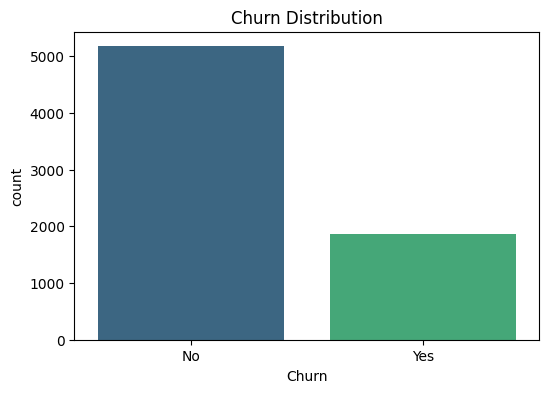

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn", palette="viridis")
plt.title("Churn Distribution")
plt.show()

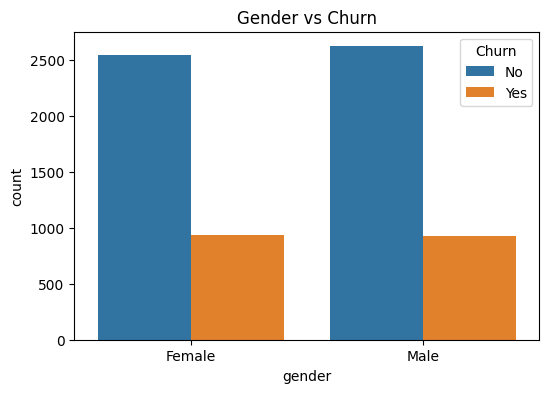

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="gender", hue="Churn")
plt.title("Gender vs Churn")
plt.show()

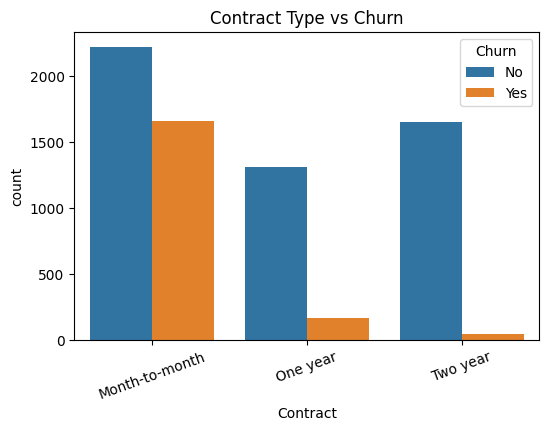

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Contract Type vs Churn")
plt.xticks(rotation=20)
plt.show()

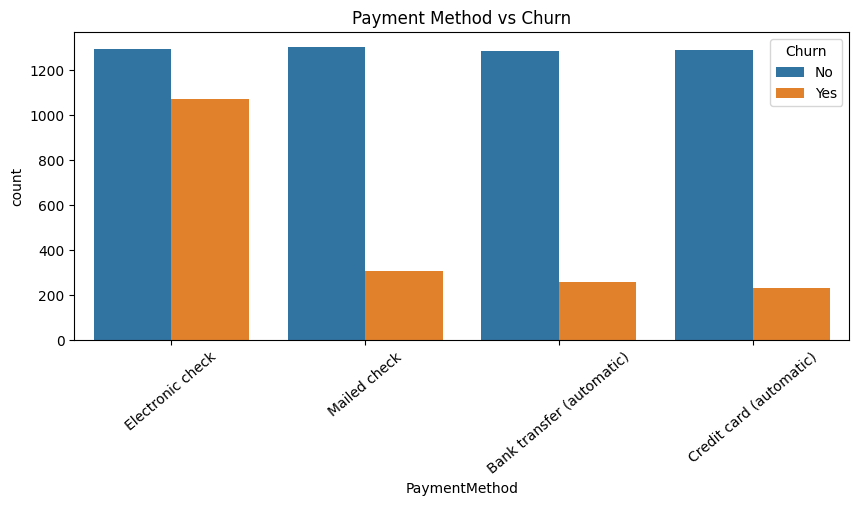

In [11]:
plt.figure(figsize=(10,4))
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.title("Payment Method vs Churn")
plt.xticks(rotation=40)
plt.show()

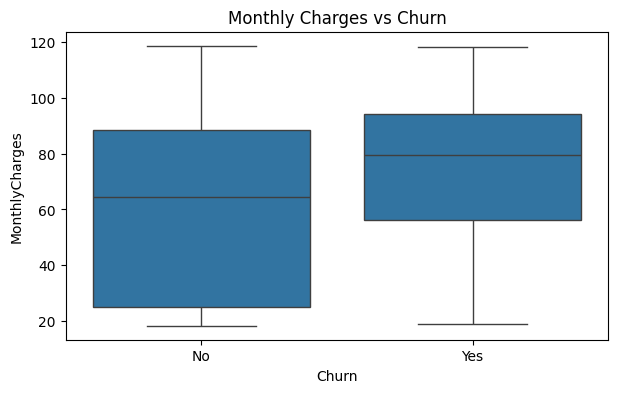

In [12]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.show()


In [14]:
corr = df.corr(numeric_only=True)

# رسم Heatmap بالـ Plotly
fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale="RdBu",
    title="Correlation Heatmap (Plotly)"
)

fig.update_layout(
    width=900,
    height=600
)

fig.show()

In [13]:
import pandas as pd
import plotly.express as px


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns